<a href="https://colab.research.google.com/github/Ayushchouhan13/AMCAT-EDA/blob/main/notebook/train_rt_detr_on_custom_dataset_with_transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Select the runtime

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `L4 GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Sun Mar  9 13:58:51 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [2]:
import os
HOME = os.getcwd()
print("HOME:", HOME)

HOME: /content


### Install dependencies

In [3]:
!pip install -q git+https://github.com/huggingface/transformers.git
!pip install -q git+https://github.com/roboflow/supervision.git
!pip install -q accelerate
!pip install -q roboflow
!pip install -q torchmetrics
!pip install -q "albumentations>=1.4.5"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━

### Imports

In [4]:
import torch
import requests

import numpy as np
import supervision as sv
import albumentations as A

from PIL import Image
from pprint import pprint
from roboflow import Roboflow
from dataclasses import dataclass, replace
from google.colab import userdata
from torch.utils.data import Dataset
from transformers import (
    AutoImageProcessor,
    AutoModelForObjectDetection,
    TrainingArguments,
    Trainer
)
from torchmetrics.detection.mean_ap import MeanAveragePrecision

## Inference with pre-trained RT-DETR model

In [5]:
# @title Load model

CHECKPOINT = "PekingU/rtdetr_r50vd_coco_o365"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForObjectDetection.from_pretrained(CHECKPOINT).to(DEVICE)
processor = AutoImageProcessor.from_pretrained(CHECKPOINT)


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


config.json:   0%|          | 0.00/5.11k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/172M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


## Fine-tune RT-DETR on custom dataset

In [6]:
# @title Download dataset from Roboflow Universe

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

project = rf.workspace("roboflow-jvuqo").project("poker-cards-fmjio")
version = project.version(4)
dataset = version.download("coco")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to poker-cards-4 in coco:: 100%|██████████| 907/907 [00:00<00:00, 5109.65it/s]


In [7]:
ds_train = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/train",
    annotations_path=f"{dataset.location}/train/_annotations.coco.json",
)
ds_valid = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/valid",
    annotations_path=f"{dataset.location}/valid/_annotations.coco.json",
)
ds_test = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/test",
    annotations_path=f"{dataset.location}/test/_annotations.coco.json",
)

print(f"Number of training images: {len(ds_train)}")
print(f"Number of validation images: {len(ds_valid)}")
print(f"Number of test images: {len(ds_test)}")

Number of training images: 811
Number of validation images: 44
Number of test images: 44


In [17]:
!pip uninstall -y supervision
!pip install supervision==0.25.0  # Install a stable version


Found existing installation: supervision 0.26.0rc4
Uninstalling supervision-0.26.0rc4:
  Successfully uninstalled supervision-0.26.0rc4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 4.0 MB/s eta 0:00:00


In [19]:
import supervision as sv
print(dir(sv))

['BackgroundOverlayAnnotator', 'BaseDataset', 'BlurAnnotator', 'BoxAnnotator', 'BoxCornerAnnotator', 'ByteTrack', 'CSVSink', 'CircleAnnotator', 'ClassificationDataset', 'Classifications', 'Color', 'ColorAnnotator', 'ColorLookup', 'ColorPalette', 'ComparisonAnnotator', 'ConfusionMatrix', 'CropAnnotator', 'DetectionDataset', 'Detections', 'DetectionsSmoother', 'DotAnnotator', 'EdgeAnnotator', 'EllipseAnnotator', 'FPSMonitor', 'HaloAnnotator', 'HeatMapAnnotator', 'IconAnnotator', 'ImageSink', 'InferenceSlicer', 'JSONSink', 'KeyPoints', 'LMM', 'LabelAnnotator', 'LineZone', 'LineZoneAnnotator', 'LineZoneAnnotatorMulticlass', 'MaskAnnotator', 'MeanAveragePrecision', 'OrientedBoxAnnotator', 'OverlapFilter', 'PercentageBarAnnotator', 'PixelateAnnotator', 'Point', 'PolygonAnnotator', 'PolygonZone', 'PolygonZoneAnnotator', 'Position', 'Rect', 'RichLabelAnnotator', 'RoundBoxAnnotator', 'TraceAnnotator', 'TriangleAnnotator', 'VLM', 'VertexAnnotator', 'VertexLabelAnnotator', 'VideoInfo', 'VideoSink

In [27]:
import cv2

def draw_bboxes(image, annotations, classes):
    # Ensure we correctly extract bounding box data
    for detection in annotations:
        bbox = detection[0]  # Assuming the first element contains bbox coordinates
        class_id = detection[1]  # Assuming the second element contains class ID

        x_min, y_min, x_max, y_max = map(int, bbox)  # Convert to integers
        label = classes[class_id]  # Get the class label

        # Draw bounding box
        cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)

        # Put label text
        cv2.putText(image, label, (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (0, 255, 0), 2)

    return image




In [29]:
print(f"Dataset length: {len(ds_train)}")  # Check dataset size

# Fetch the first sample
sample = ds_train[0] if len(ds_train) > 0 else None
print(f"First sample: {sample}")


Dataset length: 811
First sample: ('/content/poker-cards-4/train/IMG_20220316_172418_jpg.rf.e3cb4a86dc0247e71e3697aa3e9db923.jpg', array([[[228, 222, 209],
        [228, 222, 209],
        [228, 222, 209],
        ...,
        [105,  98,  83],
        [106,  99,  84],
        [106,  99,  84]],

       [[228, 222, 209],
        [228, 222, 209],
        [228, 222, 209],
        ...,
        [105,  98,  83],
        [105,  98,  83],
        [106,  99,  84]],

       [[228, 222, 209],
        [228, 222, 209],
        [228, 222, 209],
        ...,
        [104,  97,  82],
        [105,  98,  83],
        [105,  98,  83]],

       ...,

       [[196, 193, 185],
        [197, 194, 186],
        [197, 194, 186],
        ...,
        [165, 173, 173],
        [165, 173, 173],
        [165, 173, 173]],

       [[196, 193, 185],
        [196, 193, 185],
        [197, 194, 186],
        ...,
        [165, 173, 173],
        [165, 173, 173],
        [165, 173, 173]],

       [[196, 193, 185],
      

In [28]:
print(type(annotations))
print(dir(annotations))

<class 'supervision.detection.core.Detections'>
['__annotations__', '__class__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__post_init__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setitem__', '__sizeof__', '__slotnames__', '__str__', '__subclasshook__', '__weakref__', 'area', 'box_area', 'class_id', 'confidence', 'data', 'empty', 'from_azure_analyze_image', 'from_deepsparse', 'from_detectron2', 'from_easyocr', 'from_inference', 'from_lmm', 'from_mmdetection', 'from_ncnn', 'from_paddledet', 'from_sam', 'from_tensorflow', 'from_transformers', 'from_ultralytics', 'from_vlm', 'from_yolo_nas', 'from_yolov5', 'get_anchors_coordinates', 'is_empty', 'mask', 'merge', 'metadata', 'tracker_

Image shape: (640, 640, 3)


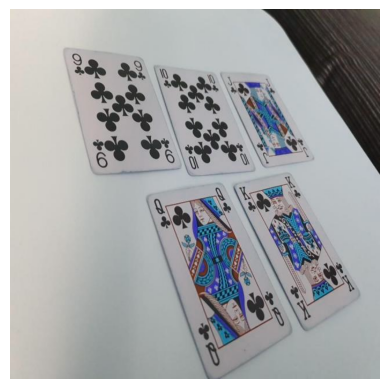

In [30]:
import matplotlib.pyplot as plt

if sample:
    _, image, annotations = sample  # Extract image & annotations
    print(f"Image shape: {image.shape}")  # Ensure it's a valid image

    plt.imshow(image)  # Display the image
    plt.axis("off")
    plt.show()
else:
    print("No valid image found in dataset!")


### Preprocess the data

To finetune a model, you must preprocess the data you plan to use to match precisely the approach used for the pre-trained model. [AutoImageProcessor](https://huggingface.co/docs/transformers/main/en/model_doc/auto#transformers.AutoImageProcessor) takes care of processing image data to create `pixel_values`, `pixel_mask`, and `labels` that a DETR model can train with. The image processor has some attributes that you won't have to worry about:

- `image_mean = [0.485, 0.456, 0.406 ]`
- `image_std = [0.229, 0.224, 0.225]`

These are the mean and standard deviation used to normalize images during the model pre-training. These values are crucial to replicate when doing inference or finetuning a pre-trained image model.

Instantiate the image processor from the same checkpoint as the model you want to finetune.

In [31]:
IMAGE_SIZE = 480

processor = AutoImageProcessor.from_pretrained(
    CHECKPOINT,
    do_resize=True,
    size={"width": IMAGE_SIZE, "height": IMAGE_SIZE},
)

Before passing the images to the `processor`, apply two preprocessing transformations to the dataset:

- Augmenting images
- Reformatting annotations to meet RT-DETR expectations

First, to make sure the model does not overfit on the training data, you can apply image augmentation with any data augmentation library. Here we use [Albumentations](https://albumentations.ai/docs/). This library ensures that transformations affect the image and update the bounding boxes accordingly.

In [32]:
train_augmentation_and_transform = A.Compose(
    [
        A.Perspective(p=0.1),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.HueSaturationValue(p=0.1),
    ],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"],
        clip=True,
        min_area=25
    ),
)

valid_transform = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"],
        clip=True,
        min_area=1
    ),
)

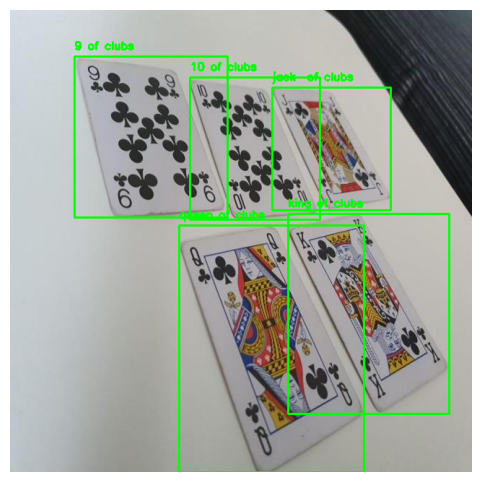

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def draw_bboxes(image, annotations, classes):
    """Draw bounding boxes using OpenCV."""
    for bbox, class_id in zip(annotations.xyxy, annotations.class_id):
        x_min, y_min, x_max, y_max = map(int, bbox)  # Convert to integers
        label = classes[class_id]  # Get class label

        # Draw bounding box
        cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)

        # Put class label on the image
        cv2.putText(image, label, (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (0, 255, 0), 2)

    return image

# Check if dataset is loaded
if len(ds_train) > 0:
    _, image, annotations = ds_train[0]  # Get first sample
    annotated_image = draw_bboxes(image, annotations, ds_train.classes)

    # Display the image using matplotlib
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB
    plt.axis("off")
    plt.show()
else:
    print("Dataset is empty. Please check the data loading process.")


In [35]:
# @title Visualize some augmented images
"""
IMAGE_COUNT = 5

for i in range(IMAGE_COUNT):
    _, image, annotations = ds_train[i]

    output = train_augmentation_and_transform(
        image=image,
        bboxes=annotations.xyxy,
        category=annotations.class_id
    )

    augmented_image = output["image"]
    augmented_annotations = replace(
        annotations,
        xyxy=np.array(output["bboxes"]),
        class_id=np.array(output["category"])
    )

    annotated_images = [
        annotate(image, annotations, ds_train.classes),
        annotate(augmented_image, augmented_annotations, ds_train.classes)
    ]
    grid = sv.create_tiles(
        annotated_images,
        titles=['original', 'augmented'],
        titles_scale=0.5,
        single_tile_size=(400, 400),
        tile_padding_color=sv.Color.WHITE,
        tile_margin_color=sv.Color.WHITE
    )
    sv.plot_image(grid, size=(6, 6))"""""

'\nIMAGE_COUNT = 5\n\nfor i in range(IMAGE_COUNT):\n    _, image, annotations = ds_train[i]\n\n    output = train_augmentation_and_transform(\n        image=image,\n        bboxes=annotations.xyxy,\n        category=annotations.class_id\n    )\n\n    augmented_image = output["image"]\n    augmented_annotations = replace(\n        annotations,\n        xyxy=np.array(output["bboxes"]),\n        class_id=np.array(output["category"])\n    )\n\n    annotated_images = [\n        annotate(image, annotations, ds_train.classes),\n        annotate(augmented_image, augmented_annotations, ds_train.classes)\n    ]\n    grid = sv.create_tiles(\n        annotated_images,\n        titles=[\'original\', \'augmented\'],\n        titles_scale=0.5,\n        single_tile_size=(400, 400),\n        tile_padding_color=sv.Color.WHITE,\n        tile_margin_color=sv.Color.WHITE\n    )\n    sv.plot_image(grid, size=(6, 6))'

The `processor` expects the annotations to be in the following format: `{'image_id': int, 'annotations': List[Dict]}`, where each dictionary is a COCO object annotation. Let's add a function to reformat annotations for a single example:

In [36]:
class PyTorchDetectionDataset(Dataset):
    def __init__(self, dataset: sv.DetectionDataset, processor, transform: A.Compose = None):
        self.dataset = dataset
        self.processor = processor
        self.transform = transform

    @staticmethod
    def annotations_as_coco(image_id, categories, boxes):
        annotations = []
        for category, bbox in zip(categories, boxes):
            x1, y1, x2, y2 = bbox
            formatted_annotation = {
                "image_id": image_id,
                "category_id": category,
                "bbox": [x1, y1, x2 - x1, y2 - y1],
                "iscrowd": 0,
                "area": (x2 - x1) * (y2 - y1),
            }
            annotations.append(formatted_annotation)

        return {
            "image_id": image_id,
            "annotations": annotations,
        }

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        _, image, annotations = self.dataset[idx]

        # Convert image to RGB numpy array
        image = image[:, :, ::-1]
        boxes = annotations.xyxy
        categories = annotations.class_id

        if self.transform:
            transformed = self.transform(
                image=image,
                bboxes=boxes,
                category=categories
            )
            image = transformed["image"]
            boxes = transformed["bboxes"]
            categories = transformed["category"]


        formatted_annotations = self.annotations_as_coco(
            image_id=idx, categories=categories, boxes=boxes)
        result = self.processor(
            images=image, annotations=formatted_annotations, return_tensors="pt")

        # Image processor expands batch dimension, lets squeeze it
        result = {k: v[0] for k, v in result.items()}

        return result

Now you can combine the image and annotation transformations to use on a batch of examples:

In [37]:
pytorch_dataset_train = PyTorchDetectionDataset(
    ds_train, processor, transform=train_augmentation_and_transform)
pytorch_dataset_valid = PyTorchDetectionDataset(
    ds_valid, processor, transform=valid_transform)
pytorch_dataset_test = PyTorchDetectionDataset(
    ds_test, processor, transform=valid_transform)

pytorch_dataset_train[15]

{'pixel_values': tensor([[[0.0745, 0.0745, 0.0745,  ..., 0.2431, 0.2471, 0.2471],
          [0.0745, 0.0745, 0.0745,  ..., 0.2510, 0.2549, 0.2549],
          [0.0667, 0.0706, 0.0706,  ..., 0.2588, 0.2588, 0.2588],
          ...,
          [0.0118, 0.0118, 0.0118,  ..., 0.0510, 0.0549, 0.0510],
          [0.0157, 0.0196, 0.0235,  ..., 0.0549, 0.0627, 0.0549],
          [0.0235, 0.0275, 0.0314,  ..., 0.0549, 0.0627, 0.0549]],
 
         [[0.0549, 0.0549, 0.0549,  ..., 0.3137, 0.3176, 0.3176],
          [0.0549, 0.0549, 0.0549,  ..., 0.3216, 0.3255, 0.3255],
          [0.0471, 0.0510, 0.0510,  ..., 0.3294, 0.3294, 0.3294],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0353, 0.0392, 0.0353],
          [0.0000, 0.0000, 0.0039,  ..., 0.0392, 0.0471, 0.0392],
          [0.0000, 0.0039, 0.0078,  ..., 0.0392, 0.0471, 0.0392]],
 
         [[0.0431, 0.0431, 0.0431,  ..., 0.3922, 0.3961, 0.3961],
          [0.0431, 0.0431, 0.0431,  ..., 0.4000, 0.4039, 0.4039],
          [0.0353, 0.039

You have successfully augmented the images and prepared their annotations. In the final step, create a custom collate_fn to batch images together.

In [38]:
def collate_fn(batch):
    data = {}
    data["pixel_values"] = torch.stack([x["pixel_values"] for x in batch])
    data["labels"] = [x["labels"] for x in batch]
    return data

## Preparing function to compute mAP

In [39]:
id2label = {id: label for id, label in enumerate(ds_train.classes)}
label2id = {label: id for id, label in enumerate(ds_train.classes)}


@dataclass
class ModelOutput:
    logits: torch.Tensor
    pred_boxes: torch.Tensor


class MAPEvaluator:

    def __init__(self, image_processor, threshold=0.00, id2label=None):
        self.image_processor = image_processor
        self.threshold = threshold
        self.id2label = id2label

    def collect_image_sizes(self, targets):
        """Collect image sizes across the dataset as list of tensors with shape [batch_size, 2]."""
        image_sizes = []
        for batch in targets:
            batch_image_sizes = torch.tensor(np.array([x["size"] for x in batch]))
            image_sizes.append(batch_image_sizes)
        return image_sizes

    def collect_targets(self, targets, image_sizes):
        post_processed_targets = []
        for target_batch, image_size_batch in zip(targets, image_sizes):
            for target, (height, width) in zip(target_batch, image_size_batch):
                boxes = target["boxes"]
                boxes = sv.xcycwh_to_xyxy(boxes)
                boxes = boxes * np.array([width, height, width, height])
                boxes = torch.tensor(boxes)
                labels = torch.tensor(target["class_labels"])
                post_processed_targets.append({"boxes": boxes, "labels": labels})
        return post_processed_targets

    def collect_predictions(self, predictions, image_sizes):
        post_processed_predictions = []
        for batch, target_sizes in zip(predictions, image_sizes):
            batch_logits, batch_boxes = batch[1], batch[2]
            output = ModelOutput(logits=torch.tensor(batch_logits), pred_boxes=torch.tensor(batch_boxes))
            post_processed_output = self.image_processor.post_process_object_detection(
                output, threshold=self.threshold, target_sizes=target_sizes
            )
            post_processed_predictions.extend(post_processed_output)
        return post_processed_predictions

    @torch.no_grad()
    def __call__(self, evaluation_results):

        predictions, targets = evaluation_results.predictions, evaluation_results.label_ids

        image_sizes = self.collect_image_sizes(targets)
        post_processed_targets = self.collect_targets(targets, image_sizes)
        post_processed_predictions = self.collect_predictions(predictions, image_sizes)

        evaluator = MeanAveragePrecision(box_format="xyxy", class_metrics=True)
        evaluator.warn_on_many_detections = False
        evaluator.update(post_processed_predictions, post_processed_targets)

        metrics = evaluator.compute()

        # Replace list of per class metrics with separate metric for each class
        classes = metrics.pop("classes")
        map_per_class = metrics.pop("map_per_class")
        mar_100_per_class = metrics.pop("mar_100_per_class")
        for class_id, class_map, class_mar in zip(classes, map_per_class, mar_100_per_class):
            class_name = id2label[class_id.item()] if id2label is not None else class_id.item()
            metrics[f"map_{class_name}"] = class_map
            metrics[f"mar_100_{class_name}"] = class_mar

        metrics = {k: round(v.item(), 4) for k, v in metrics.items()}

        return metrics

eval_compute_metrics_fn = MAPEvaluator(image_processor=processor, threshold=0.01, id2label=id2label)

## Training the detection model

You have done most of the heavy lifting in the previous sections, so now you are ready to train your model! The images in this dataset are still quite large, even after resizing. This means that finetuning this model will require at least one GPU.

Training involves the following steps:

- Load the model with [`AutoModelForObjectDetection`](https://huggingface.co/docs/transformers/main/en/model_doc/auto#transformers.AutoModelForObjectDetection) using the same checkpoint as in the preprocessing.
- Define your training hyperparameters in [`TrainingArguments`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.TrainingArguments).
- Pass the training arguments to [`Trainer`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer) along with the model, dataset, image processor, and data collator.
- Call [`train()`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer.train) to finetune your model.

When loading the model from the same checkpoint that you used for the preprocessing, remember to pass the `label2id` and `id2label` maps that you created earlier from the dataset's metadata. Additionally, we specify `ignore_mismatched_sizes=True` to replace the existing classification head with a new one.

In [40]:
model = AutoModelForObjectDetection.from_pretrained(
    CHECKPOINT,
    id2label=id2label,
    label2id=label2id,
    anchor_image_size=None,
    ignore_mismatched_sizes=True,
)

Some weights of RTDetrForObjectDetection were not initialized from the model checkpoint at PekingU/rtdetr_r50vd_coco_o365 and are newly initialized because the shapes did not match:
- model.decoder.class_embed.0.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([53]) in the model instantiated
- model.decoder.class_embed.0.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([53, 256]) in the model instantiated
- model.decoder.class_embed.1.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([53]) in the model instantiated
- model.decoder.class_embed.1.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([53, 256]) in the model instantiated
- model.decoder.class_embed.2.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([53]) in the model instantiated
- model.decoder.class_embed.2.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([53, 256]) in the model instantiated
- 

In the [`TrainingArguments`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.TrainingArguments) use `output_dir` to specify where to save your model, then configure hyperparameters as you see fit. For `num_train_epochs=10` training will take about 15 minutes in Google Colab T4 GPU, increase the number of epoch to get better results.

Important notes:

- Do not remove unused columns because this will drop the image column. Without the image column, you can't create `pixel_values`. For this reason, set `remove_unused_columns` to `False`.
- Set `eval_do_concat_batches=False` to get proper evaluation results. Images have different number of target boxes, if batches are concatenated we will not be able to determine which boxes belongs to particular image.

In [43]:
training_args = TrainingArguments(
    output_dir=f"{dataset.name.replace(' ', '-')}-finetune",
    num_train_epochs=10,
    max_grad_norm=0.1,
    learning_rate=5e-5,
    warmup_steps=300,
    per_device_train_batch_size=16,
    dataloader_num_workers=2,
    metric_for_best_model="eval_map",
    greater_is_better=True,
    load_best_model_at_end=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    remove_unused_columns=False,
    eval_do_concat_batches=False,
)

Finally, bring everything together, and call [`train()`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer.train):

In [44]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=pytorch_dataset_train,
    eval_dataset=pytorch_dataset_valid,
    tokenizer=processor,
    data_collator=collate_fn,
    compute_metrics=eval_compute_metrics_fn,
)

trainer.train()

`tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.


Epoch,Training Loss,Validation Loss,Map,Map 50,Map 75,Map Small,Map Medium,Map Large,Mar 1,Mar 10,Mar 100,Mar Small,Mar Medium,Mar Large,Map Cards,Mar 100 Cards,Map 10 of clubs,Mar 100 10 of clubs,Map 10 of diamonds,Mar 100 10 of diamonds,Map 10 of hearts,Mar 100 10 of hearts,Map 10 of spades,Mar 100 10 of spades,Map 2 of clubs,Mar 100 2 of clubs,Map 2 of diamonds,Mar 100 2 of diamonds,Map 2 of hearts,Mar 100 2 of hearts,Map 2 of spades,Mar 100 2 of spades,Map 3 of clubs,Mar 100 3 of clubs,Map 3 of diamonds,Mar 100 3 of diamonds,Map 3 of hearts,Mar 100 3 of hearts,Map 3 of spades,Mar 100 3 of spades,Map 4 of clubs,Mar 100 4 of clubs,Map 4 of diamonds,Mar 100 4 of diamonds,Map 4 of hearts,Mar 100 4 of hearts,Map 4 of spades,Mar 100 4 of spades,Map 5 of clubs,Mar 100 5 of clubs,Map 5 of diamonds,Mar 100 5 of diamonds,Map 5 of hearts,Mar 100 5 of hearts,Map 5 of spades,Mar 100 5 of spades,Map 6 of clubs,Mar 100 6 of clubs,Map 6 of diamonds,Mar 100 6 of diamonds,Map 6 of hearts,Mar 100 6 of hearts,Map 6 of spades,Mar 100 6 of spades,Map 7 of clubs,Mar 100 7 of clubs,Map 7 of diamonds,Mar 100 7 of diamonds,Map 7 of hearts,Mar 100 7 of hearts,Map 7 of spades,Mar 100 7 of spades,Map 8 of clubs,Mar 100 8 of clubs,Map 8 of diamonds,Mar 100 8 of diamonds,Map 8 of hearts,Mar 100 8 of hearts,Map 8 of spades,Mar 100 8 of spades,Map 9 of clubs,Mar 100 9 of clubs,Map 9 of diamonds,Mar 100 9 of diamonds,Map 9 of hearts,Mar 100 9 of hearts,Map 9 of spades,Mar 100 9 of spades,Map Ace of clubs,Mar 100 Ace of clubs,Map Ace of diamonds,Mar 100 Ace of diamonds,Map Ace of hearts,Mar 100 Ace of hearts,Map Ace of spades,Mar 100 Ace of spades,Map Jack of clubs,Mar 100 Jack of clubs,Map Jack of diamonds,Mar 100 Jack of diamonds,Map Jack of hearts,Mar 100 Jack of hearts,Map Jack of spades,Mar 100 Jack of spades,Map King of clubs,Mar 100 King of clubs,Map King of diamonds,Mar 100 King of diamonds,Map King of hearts,Mar 100 King of hearts,Map King of spades,Mar 100 King of spades,Map Queen of clubs,Mar 100 Queen of clubs,Map Queen of diamonds,Mar 100 Queen of diamonds,Map Queen of hearts,Mar 100 Queen of hearts,Map Queen of spades,Mar 100 Queen of spades
1,No log,30.907763,0.008400,0.010000,0.010000,-1.000000,-1.000000,0.009400,0.033800,0.040400,0.042800,-1.000000,-1.000000,0.042800,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.002700,0.228600,0.000000,0.000000,0.000000,0.000000,0.008200,0.350000,0.000000,0.000000,0.231700,0.225000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000900,0.125000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.117800,0.233300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.056100,0.333300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005000,0.114300,0.000000,0.000000,0.011000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002700,0.114300,0.000000,0.000000
2,No log,25.802971,0.016400,0.019200,0.017600,-1.000000,-1.000000,0.017100,0.067000,0.227600,0.236300,-1.000000,-1.000000,0.236300,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.015200,0.500000,0.044300,0.675000,0.101000,0.500000,0.000000,0.000000,0.000000,0.000000,0.021500,0.250000,0.038800,0.500000,0.004600,0.450000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005500,0.525000,0.000000,0.000000,0.056300,0.633300,0.000000,0.000000,0.000000,0.000000,0.033800,0.285700,0.076400,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.018700,0.333300,0.000000,0.000000,0.023200,0.428600,0.016800,0.633300,0.033000,0.633300,0.000000,0.000000,0.007300,0.400000,0.002

There were missing keys in the checkpoint model loaded: ['class_embed.0.weight', 'class_embed.0.bias', 'class_embed.1.weight', 'class_embed.1.bias', 'class_embed.2.weight', 'class_embed.2.bias', 'class_embed.3.weight', 'class_embed.3.bias', 'class_embed.4.weight', 'class_embed.4.bias', 'class_embed.5.weight', 'class_embed.5.bias', 'bbox_embed.0.layers.0.weight', 'bbox_embed.0.layers.0.bias', 'bbox_embed.0.layers.1.weight', 'bbox_embed.0.layers.1.bias', 'bbox_embed.0.layers.2.weight', 'bbox_embed.0.layers.2.bias', 'bbox_embed.1.layers.0.weight', 'bbox_embed.1.layers.0.bias', 'bbox_embed.1.layers.1.weight', 'bbox_embed.1.layers.1.bias', 'bbox_embed.1.layers.2.weight', 'bbox_embed.1.layers.2.bias', 'bbox_embed.2.layers.0.weight', 'bbox_embed.2.layers.0.bias', 'bbox_embed.2.layers.1.weight', 'bbox_embed.2.layers.1.bias', 'bbox_embed.2.layers.2.weight', 'bbox_embed.2.layers.2.bias', 'bbox_embed.3.layers.0.weight', 'bbox_embed.3.layers.0.bias', 'bbox_embed.3.layers.1.weight', 'bbox_embed.3.l

TrainOutput(global_step=510, training_loss=29.1947192921358, metrics={'train_runtime': 932.1371, 'train_samples_per_second': 8.7, 'train_steps_per_second': 0.547, 'total_flos': 1.440268359952896e+18, 'train_loss': 29.1947192921358, 'epoch': 10.0})

## Evaluate

In [45]:
# @title Collect predictions

targets = []
predictions = []

for i in range(len(ds_test)):
    path, sourece_image, annotations = ds_test[i]

    image = Image.open(path)
    inputs = processor(image, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    w, h = image.size
    results = processor.post_process_object_detection(
        outputs, target_sizes=[(h, w)], threshold=0.3)

    detections = sv.Detections.from_transformers(results[0])

    targets.append(annotations)
    predictions.append(detections)

In [46]:
# @title Calculate mAP
mean_average_precision = sv.MeanAveragePrecision.from_detections(
    predictions=predictions,
    targets=targets,
)

print(f"map50_95: {mean_average_precision.map50_95:.2f}")
print(f"map50: {mean_average_precision.map50:.2f}")
print(f"map75: {mean_average_precision.map75:.2f}")

map50_95: 0.17
map50: 0.17
map75: 0.17


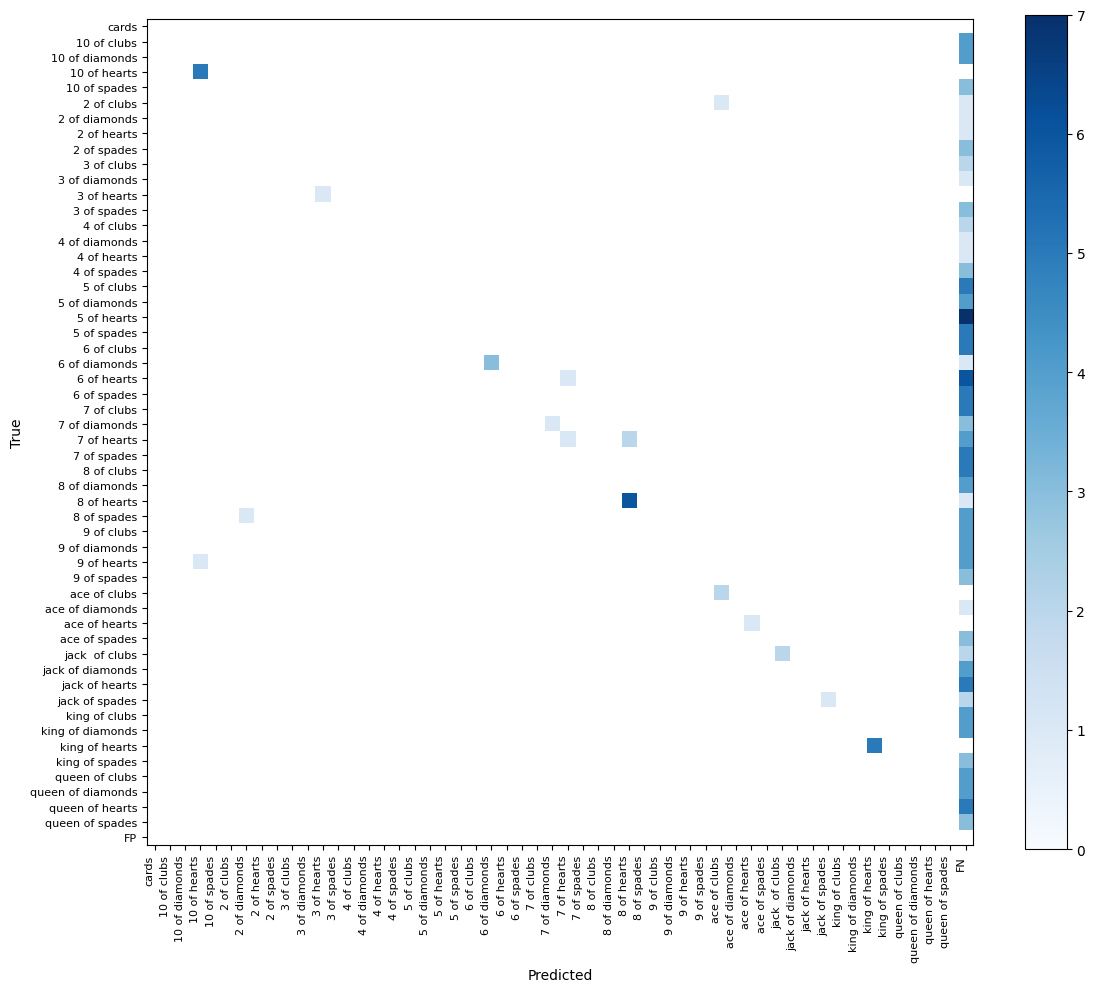

In [47]:
# @title Calculate Confusion Matrix
confusion_matrix = sv.ConfusionMatrix.from_detections(
    predictions=predictions,
    targets=targets,
    classes=ds_test.classes
)

_ = confusion_matrix.plot()

## Save fine-tuned model on hard drive

In [48]:
model.save_pretrained("/content/rt-detr/")
processor.save_pretrained("/content/rt-detr/")

['/content/rt-detr/preprocessor_config.json']

## Inference with fine-tuned RT-DETR model

In [49]:
IMAGE_COUNT = 5

for i in range(IMAGE_COUNT):
    path, sourece_image, annotations = ds_test[i]

    image = Image.open(path)
    inputs = processor(image, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    w, h = image.size
    results = processor.post_process_object_detection(
        outputs, target_sizes=[(h, w)], threshold=0.3)

    detections = sv.Detections.from_transformers(results[0]).with_nms(threshold=0.1)

    annotated_images = [
        annotate(sourece_image, annotations, ds_train.classes),
        annotate(sourece_image, detections, ds_train.classes)
    ]
    grid = sv.create_tiles(
        annotated_images,
        titles=['ground truth', 'prediction'],
        titles_scale=0.5,
        single_tile_size=(400, 400),
        tile_padding_color=sv.Color.WHITE,
        tile_margin_color=sv.Color.WHITE
    )
    sv.plot_image(grid, size=(6, 6))

AttributeError: module 'supervision' has no attribute 'BoundingBoxAnnotator'